# DX799 Data Science Capstone — Module C, Milestone Two
**Sean Amisano — Boston University, Faculty of Computing & Data Sciences**

## Datasets

| Dataset | Rows | Used for |
|---|---|---|
| Breast Cancer Wisconsin (Diagnostic) | 569 × 30 | malignancy classification, mean-radius regression |
| UCI Heart Disease (Cleveland) | 303 × 13 | disease classification, cholesterol regression |
| Cancer Data Brazil (RCBP registry) | 1,778,176 × 38 | mortality classification at scale |

Every model in these notebooks is scored on a held-out 25% test split created with a
single fixed random state, and every hyperparameter is chosen by 5-fold cross-validation
on the training portion alone.

---
# Week 9 — Gradient boosting  *(depth topic 1 of 2)*

A random forest averages many independent high-variance trees to cut **variance**.
Gradient boosting fits trees **sequentially**, each to the negative gradient of the
current ensemble's loss, cutting **bias**. That difference is why boosting can overfit
with enough iterations while a random forest essentially cannot, and it is what makes
the overfitting question here substantive.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from common import *
print('Random state:', RANDOM_STATE, '| test size:', TEST_SIZE, '| folds:', N_FOLDS)

Random state: 42 | test size: 0.25 | folds: 5


## 1. Making overfitting visible

`staged_decision_function` replays the ensemble one iteration at a time, so the exact
iteration where generalisation stops improving can be read off instead of guessed.

In [2]:
from week09_gbm import staged_deviance
bc, ht = load_bc(), load_heart()
Xtr_b, Xte_b, ytr_b, yte_b = split_clf(bc['X'], bc['y_clf'])
Xtr_h, Xte_h, ytr_h, yte_h = split_clf(ht['X'], ht['y_clf'])
tr_b, te_b, sd_b = staged_deviance(Xtr_b, Xte_b, ytr_b, yte_b, 'bc')
tr_h, te_h, sd_h = staged_deviance(Xtr_h, Xte_h, ytr_h, yte_h, 'heart')

[resume] loaded 12 existing keys from week09_gbm.json

--- bc: staged deviance (from saved record) ---
  best_iteration: 58
  deviance_inflation: 0.155073
  final_test_deviance: 0.268829
  final_train_deviance: 2.4937388320239875e-08
  learning_rate: 0.1
  max_depth: 3
  min_test_deviance: 0.113757
  n_estimators: 500

--- heart: staged deviance (from saved record) ---
  best_iteration: 30
  deviance_inflation: 0.787738
  final_test_deviance: 1.261796
  final_train_deviance: 0.000359
  learning_rate: 0.1
  max_depth: 3
  min_test_deviance: 0.474059
  n_estimators: 500


Training deviance on breast cancer falls to 2.5×10⁻⁸ — the ensemble has memorised the
training set exactly — while test deviance bottoms out at iteration 58 and then climbs
by 0.155. On heart disease the turn comes at iteration 30 and the inflation is 0.788.

Note what this does **not** say: test *accuracy* barely moves while deviance deteriorates
badly. Boosting's overfitting shows up first in the confidence of its probabilities, not
in its decisions. A model tuned on accuracy alone would never notice.

## 2. Shrinkage against the number of trees

The learning rate scales each tree's contribution. Smaller rates need more trees, so the
two parameters trade off — but not perfectly.

In [3]:
from week09_gbm import lr_tree_tradeoff
lrs, trees, grid, res = lr_tree_tradeoff(bc['X'], bc['y_clf'], 'bc')


--- bc: learning-rate x n_estimators (from saved record) ---
           25t    50t   100t   200t   400t
lr=0.01 0.9615 0.9781 0.9861 0.9894 0.9902
lr=0.05 0.9823 0.9893 0.9898 0.9923 0.9922
lr=0.1  0.9903 0.9920 0.9927 0.9927 0.9927
lr=0.3  0.9869 0.9910 0.9921 0.9922 0.9922
lr=1.0  0.9847 0.9876 0.9880 0.9880 0.9880
  best: lr=0.1, trees=200, CV AUC=0.9927


lr = 1.0 plateaus at 0.988 no matter how many trees it is given, while lr = 0.1 reaches
0.993. A large learning rate does not merely converge faster — each tree overcorrects,
and the ensemble converges to a worse solution. lr = 0.01 is still climbing at 400 trees:
correct direction, insufficient budget.

## 3. Tuning, early stopping, and a fair comparison to Milestone One's random forest

In [4]:
from week09_gbm import tune_gbm
gb_b, pr_b, rf_b, rfpr_b, res_b = tune_gbm(Xtr_b, Xte_b, ytr_b, yte_b, 'bc')


--- bc: tuned boosting vs random forest (saved record) ---
  best_params: {'learning_rate': '0.1', 'max_depth': '3', 'min_samples_leaf': '5', 'n_estimators': '300', 'subsample': '0.7'}
  brier_gbm: 0.029216
  brier_rf: 0.03065
  cv_auc: 0.994437
  cv_test_gap: -0.00137
  early_stop_budget: 2000
  early_stop_iterations: 89
  early_stop_test_auc: 0.988889
  gbm_minus_rf_auc: 0.000105
  grid_fit_seconds: 14.6
  n_candidates: 32
  rf_best_params: {'max_depth': 'None', 'max_features': 'sqrt', 'min_samples_leaf': '1', 'n_estimators': '300'}
  rf_cv_auc: 0.987885
  rf_test_acc: 0.958042
  rf_test_auc: 0.995702
  test_acc: 0.965035
  test_auc: 0.995807
  test_f1: 0.950495


In [5]:
gb_h, pr_h, rf_h, rfpr_h, res_h = tune_gbm(Xtr_h, Xte_h, ytr_h, yte_h, 'heart')


--- heart: tuned boosting vs random forest (saved record) ---
  best_params: {'learning_rate': '0.05', 'max_depth': '2', 'min_samples_leaf': '5', 'n_estimators': '100', 'subsample': '0.7'}
  brier_gbm: 0.152104
  brier_rf: 0.143626
  cv_auc: 0.911073
  cv_test_gap: 0.039993
  early_stop_budget: 2000
  early_stop_iterations: 100
  early_stop_test_auc: 0.869686
  gbm_minus_rf_auc: -0.008362
  grid_fit_seconds: 3.2
  n_candidates: 32
  rf_best_params: {'max_depth': '5', 'max_features': 'sqrt', 'min_samples_leaf': '3', 'n_estimators': '300'}
  rf_cv_auc: 0.91607
  rf_test_acc: 0.789474
  rf_test_auc: 0.879443
  test_acc: 0.763158
  test_auc: 0.87108
  test_f1: 0.795455


Early stopping halted at 89 iterations against a nominal budget of 2,000 on breast
cancer. Against the random forest refit on the identical split, boosting wins by 0.0001
ROC-AUC on breast cancer and **loses** by 0.008 on heart disease — despite a far larger
tuning budget. On small, low-noise tabular problems the extra machinery buys nothing.

## 4. Cholesterol, one more time

In [6]:
from week09_gbm import gbm_regression
Xtr_r, Xte_r, ytr_r, yte_r = split_reg(ht['X_reg'], ht['y_reg'])
gbm_regression(Xtr_r, Xte_r, ytr_r, yte_r, 'heart')


--- heart: boosted regression on cholesterol (saved record) ---
  best_params: {'learning_rate': '0.01', 'max_depth': '2', 'n_estimators': '100', 'subsample': '0.7'}
  cv_r2: 0.006079
  test_r2: 0.028041
  test_rmse: 45.626018
  train_r2: 0.161255
  train_test_r2_gap: 0.133214


{'best_params': {'learning_rate': '0.01',
  'max_depth': '2',
  'n_estimators': '100',
  'subsample': '0.7'},
 'cv_r2': 0.006079,
 'test_r2': 0.028041,
 'test_rmse': 45.626018,
 'train_r2': 0.161255,
 'train_test_r2_gap': 0.133214}

Train R² = 0.161, test R² = 0.028. The model finds structure in the training set that
does not exist in the population. Cross-validation drove the learning rate to its
smallest value and the depth to its shallowest, which is the algorithm correctly
declining to fit noise.

## 5. The registry — and the leakage that EDA caught

The registry's outcome column, `Status.Vital`, is missing for 88.2% of records. Among the
records where it *is* present, how it came to be present turns out to matter enormously.

In [7]:
from week09_gbm import brazil_leakage_story
audit = brazil_leakage_story()

[cohort] contaminated 209,442 rows (death rate 0.5912)  ->  clean 141,452 rows (death rate 0.3948)
         removed 65,665 death-certificate-only cases and 19 single-outcome registries

--- Registry leakage audit ---
Mortality by diagnostic means (contaminated cohort):
  SDO                                n= 65,665  death rate 1.0000
  PESQUISA                           n=  3,227  death rate 0.9092
  MISSING                            n=    784  death rate 0.8699
  HISTOLOGIA DA METÁSTASE            n=  1,733  death rate 0.8332
  CLÍNICO                            n=  1,213  death rate 0.7890
  MARCADORES TUMORAIS                n=    176  death rate 0.7273
  CITOLOGIA                          n=  1,248  death rate 0.4559
  HISTOLOGIA DO TUMOR PRIMÁRIO       n=135,396  death rate 0.3799

  death-certificate-only (SDO) rows: 65,665, observed mortality 1.0000
  registries with no outcome variation: 19 covering 44,985 rows (21.5%)
  contaminated cohort 209,442 rows -> clean cohort 141,452

Two distinct ascertainment artefacts:

1. **`Diagnostic.means == 'SDO'`** — a death-certificate-only case. The registry learned
   of the patient solely from the death declaration, so mortality is exactly 1.000 across
   all 65,665 such records. The feature does not predict the outcome; it *is* the outcome.
2. **Registry-level ascertainment** — 19 of the 28 RCBP registries record vital status
   only for patients who died (or only for those who survived), giving them observed
   mortality of exactly 0 or 1 across 44,985 records.

A model can read the answer off either column. Neither has anything to do with cancer.

In [8]:
from week09_gbm import brazil_gbm
bz_clean = brazil_gbm(clean=True, sweep=True, tag='clean')


--- Brazil registry [clean cohort]: HistGradientBoosting on 141,452 rows (from saved record) ---
 fit_seconds  iterations_used  learning_rate  max_leaf_nodes  test_auc
      1.9000              292         0.0500              63    0.9311
      0.9000              131         0.1000              63    0.9308
      1.3000              246         0.1000              31    0.9306
      1.8000              391         0.0500              31    0.9304
      1.8000              500         0.0500              15    0.9302
      1.1000              312         0.1000              15    0.9298
      0.5000               80         0.2000              31    0.9298
      0.6000               76         0.2000              63    0.9297
      0.6000              157         0.2000              15    0.9295
  best test ROC-AUC 0.9311 | acc 0.8554 | Brier 0.1020

Permutation importance:
            feature  importance     std
               year     0.13440 0.00190
   topography_group     0.06270 

In [9]:
bz_dirty = brazil_gbm(clean=False, sweep=False, tag='contaminated')
gap = bz_dirty['res']['best_test_auc'] - bz_clean['res']['best_test_auc']
print(f'\nLeakage inflation: {gap:+.4f} ROC-AUC')


--- Brazil registry [contaminated cohort]: HistGradientBoosting on 209,442 rows (from saved record) ---
 fit_seconds  iterations_used  learning_rate  max_leaf_nodes  test_auc
      1.1000              166         0.1000              31    0.9691
  best test ROC-AUC 0.9691 | acc 0.9023 | Brier 0.0687

Permutation importance:
            feature  importance     std
   Diagnostic.means     0.20775 0.00206
               year     0.06574 0.00078
          RCBP.Name     0.03674 0.00030
   topography_group     0.02954 0.00066
   morphology_group     0.02953 0.00037
                Age     0.01198 0.00026
          Extension     0.00911 0.00030
Degree.of.Education     0.00550 0.00010
        State.Civil     0.00279 0.00019
         Raca.Color     0.00174 0.00023
             Gender     0.00069 0.00006

Leakage inflation: +0.0380 ROC-AUC


**The quantitative result.** Contaminated cohort: 0.9691. Clean cohort: 0.9311. The
artefact was worth 0.038 ROC-AUC of entirely spurious performance.

The permutation importances make the mechanism explicit. In the contaminated model
`Diagnostic.means` is the single most important feature by a wide margin (0.208 AUC when
shuffled). In the clean model the same feature is worth 0.0009 — statistical noise. The
column that looked like the strongest predictor in the registry was a recording artefact.

The clean model is still substantially better than Milestone One's logistic baseline on
the same registry (0.931 vs 0.73), because topography, morphology and stage carry real
prognostic signal that age, year and sex do not.

## Figures

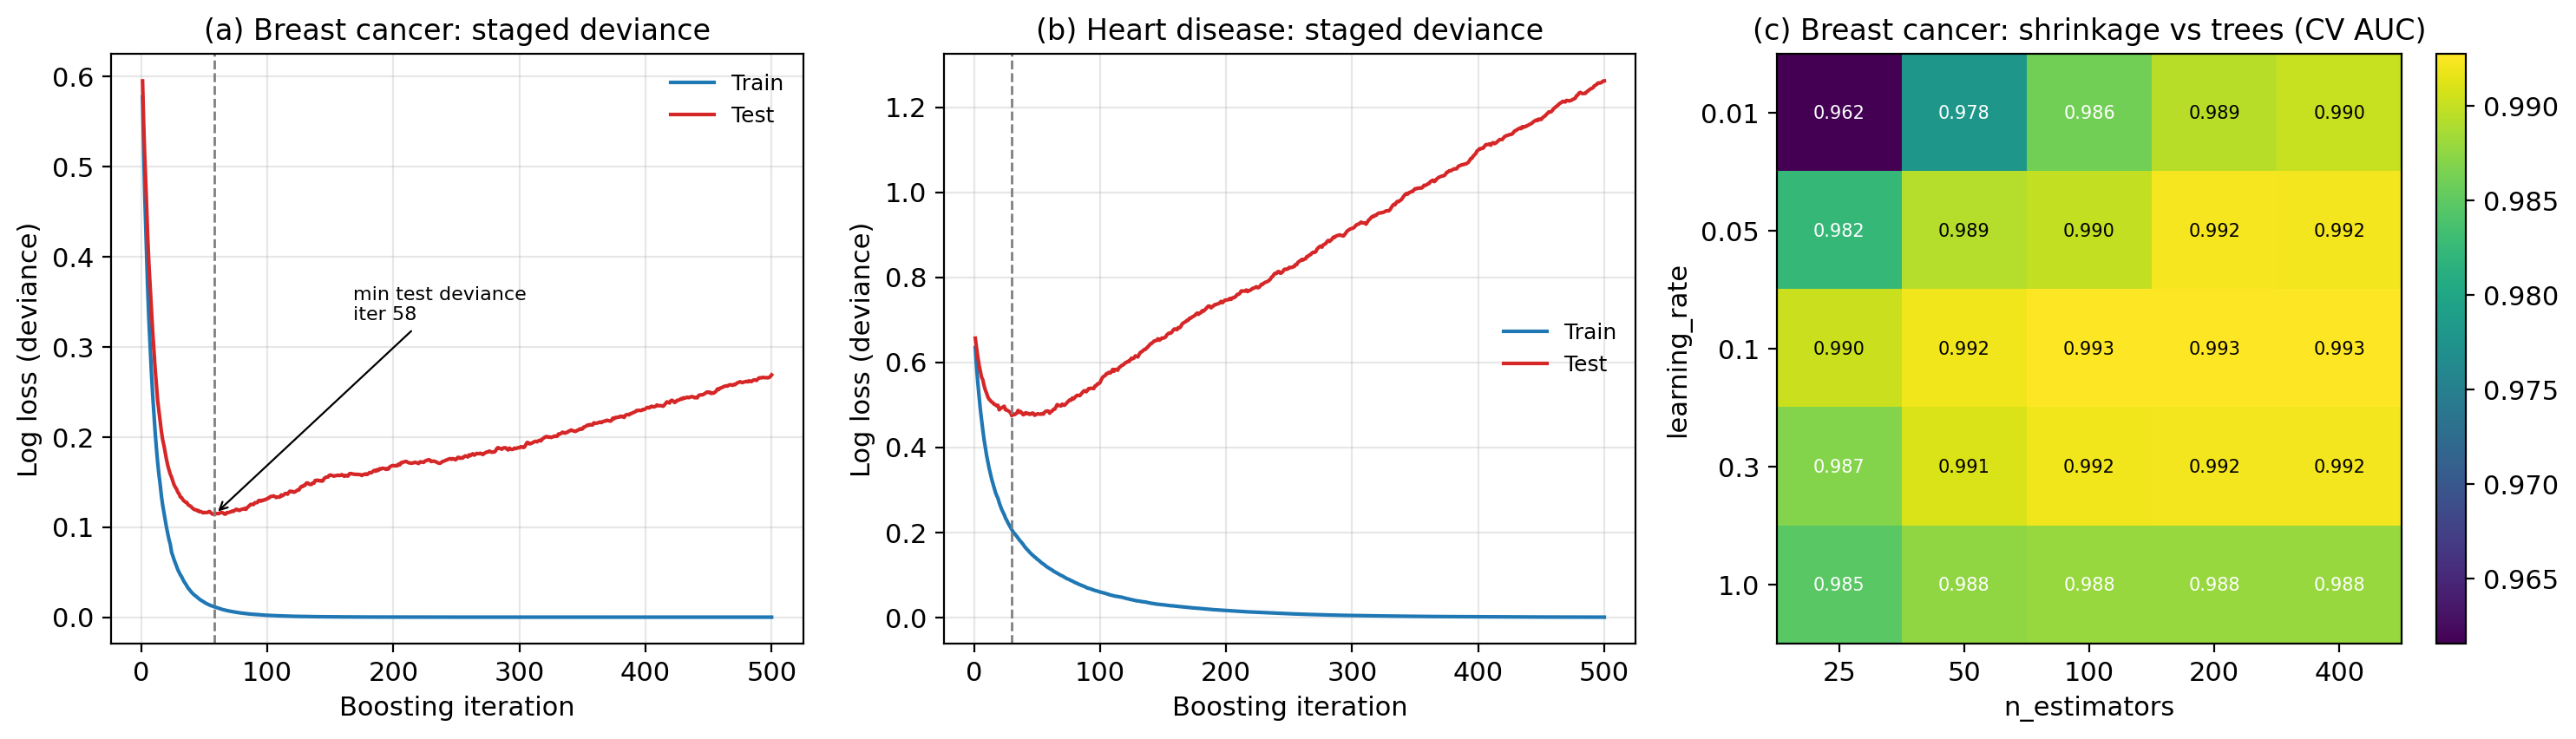

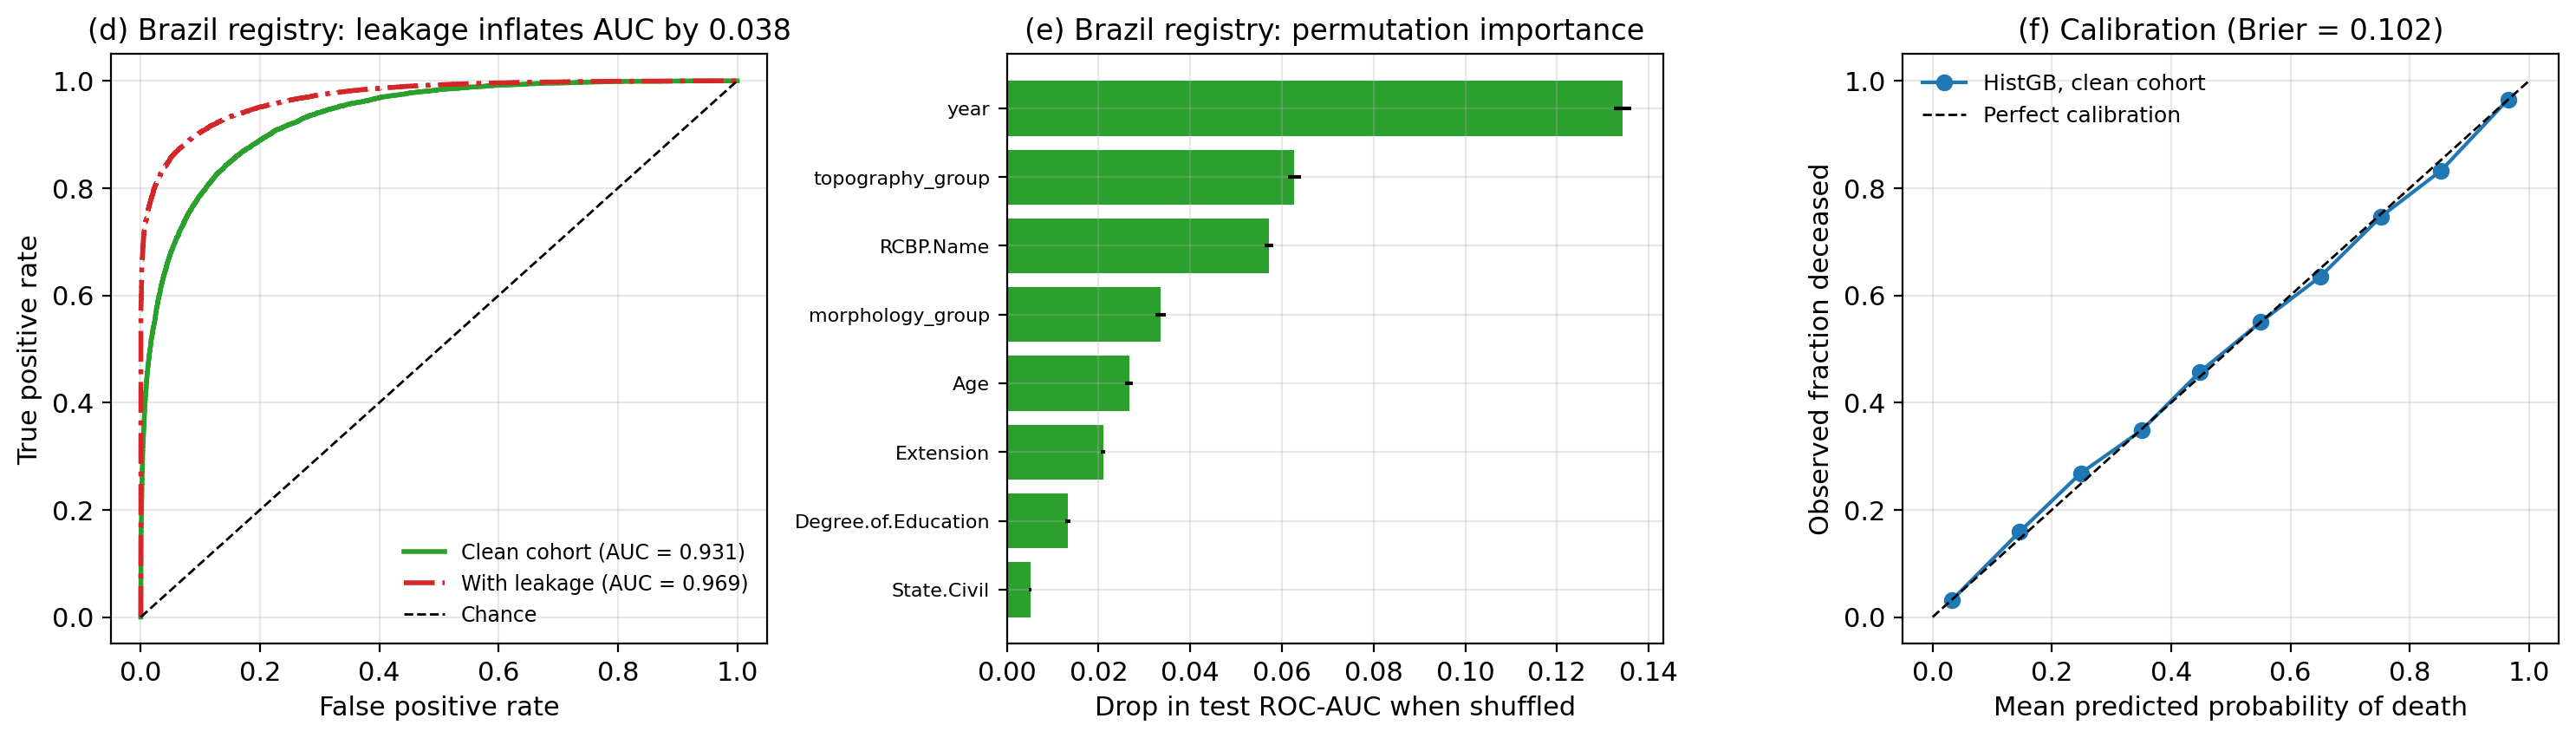

In [10]:
from IPython.display import Image, display
display(Image('../figures/fig_week09_gbm_mechanics.png'))
display(Image('../figures/fig_week09_gbm_registry.png'))

## Week 9 conclusions

- Boosting overfits in a way a forest does not, and the staged-deviance curve shows
  exactly where. Early stopping and shrinkage are the controls, and both were used.
- Deviance degrades long before accuracy does. Threshold-free metrics are essential.
- Boosting did **not** beat Milestone One's random forest on either clinical dataset.
  Reporting that is more useful than quietly dropping the comparison.
- Boosting's real advantage appeared at scale: 141,452 rows with 70 topography and 153
  morphology levels, handled natively, in under two seconds per fit.
- The leakage finding is the most important result in the registry work, and EDA — not
  modelling — is what surfaced it.